# TP n°0
Un premier essai de classification par regression régularisée (ridge)

Taille du jeu de données = (1200, 2)


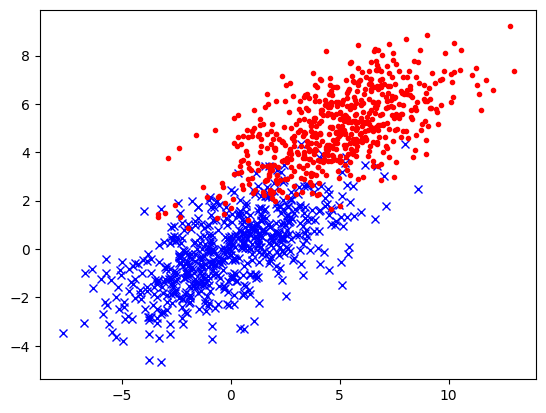

In [1]:
%matplotlib inline

#On commence par importer des modules basique Python
import numpy as np
import matplotlib.pyplot as plt

#Nombre et taille des données à générer (2D pour affichage)
n, dim = 600, 2
#Paramètre de génération pseudo-aléatoire des données (pour la reproductibilité)
np.random.seed(0)
C = np.array([[2.67, 0.7], [0.7, 1.45]])
Xtrain = np.r_[np.dot(np.random.randn(n, dim), C) , np.dot(np.random.randn(n, dim), C) + np.array([5, 5])]

#C = np.array([[1.5, 0.3], [0.3, 0.5]])
#Xtrain = np.r_[ - np.abs( np.dot(np.random.randn(n, dim), C)) + np.array([5, -0.1]) , np.abs(np.dot(np.random.randn(n, dim), C))]
# Ici j'ai choisi de générer des labels "-1 / 1"
Ltrain = np.hstack((-1*np.ones(n), np.ones(n)))

#On affiche le dataset
print('Taille du jeu de données = '+ str(Xtrain.shape) )
plt.figure(0)
plt.plot(Xtrain[:n,0],Xtrain[:n,1],'xb')
plt.plot(Xtrain[n+1:2*n,0],Xtrain[n+1:2*n,1],'.r')
plt.show()


Taux de FP = 0.4816666666666667
Taux de FN = 0.0016666666666666668
Taux d erreur = 0.24166666666666667


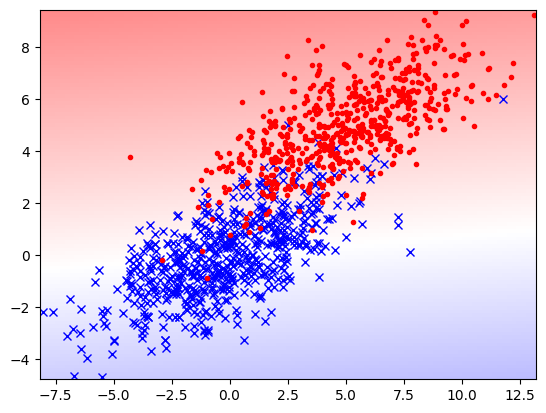

Vec Projection = 
[-0.01335118  0.18286936]


In [3]:
# En utilisant l'exemple ci-dessus on génère des données de test :

Xtest = np.r_[np.dot(np.random.randn(n, dim), C) , np.dot(np.random.randn(n, dim), C) + np.array([5, 5])]
#Xtest = np.r_[ - np.abs( np.dot(np.random.randn(n, dim), C)) + np.array([5, -0.1]) , np.abs(np.dot(np.random.randn(n, dim), C))]
Ltest = np.hstack((-1*np.ones(n), np.ones(n)))

# Maintenant à l'aide de numpy (np) faite une simple regression linéaire régularisée (classifieur ridge) :
#CODE MANQUANT !!!
VecProj = np.linalg.inv( np.dot( np.transpose(Xtrain) , Xtrain ) ) @ np.transpose(Xtrain) @ Ltrain
Lestim = Xtest @ VecProj

# Et evaluez ses performances (taux de faux-positifs / faux négatifs) sur les données de test
#CODE MANQUANT (ENCORE) !!!
nbFP = np.sum( Lestim[Ltest==-1] > 0)
nbFN = np.sum( Lestim[Ltest==1] <= 0)
TauxFP = nbFP / np.sum( Ltest==-1 )
TauxFN  = nbFN / np.sum( Ltest==1 )
TauxErreur = (nbFP + nbFN) / ( Ltest.shape[0] )
print('Taux de FP = ' + str(TauxFP))
print('Taux de FN = ' + str(TauxFN))
print('Taux d erreur = ' + str(TauxErreur))


# SI VOUS VOULEZ ALLER PLUS LOIN !!
# Comment faire pour visualiser la "frontière de décision" ?
# Indice : classifier des points répartis régulièrement !
# Tracer les données et la frontière de décision
x1 = np.linspace(np.min(Xtest[:,0]) , np.max(Xtest[:,0]) , 101)
x2 = np.linspace(np.min(Xtest[:,1]) , np.max(Xtest[:,1]) , 101)
X1, X2 = np.meshgrid(x1, x2)
GridXY = np.c_[ X1.flatten() , X2.flatten()]

resultatGrid = GridXY @ VecProj
DecisionBoundary = np.reshape(resultatGrid , X1.shape)

plt.figure()
plt.plot(Xtest[:n,0],Xtest[:n,1],'xb')
plt.plot(Xtest[n+1:2*n,0],Xtest[n+1:2*n,1],'.r')
plt.pcolormesh(x1, x2, DecisionBoundary , cmap=plt.cm.bwr, alpha=0.5, vmax=2, vmin=-2)

# Pour que l'affichage soit clair, j'ai limité à -2 et 2 l'affichage des couleurs (pour que la ligne blanche soit sur 0.5)
plt.show()

print('Vec Projection = ')
print(VecProj)


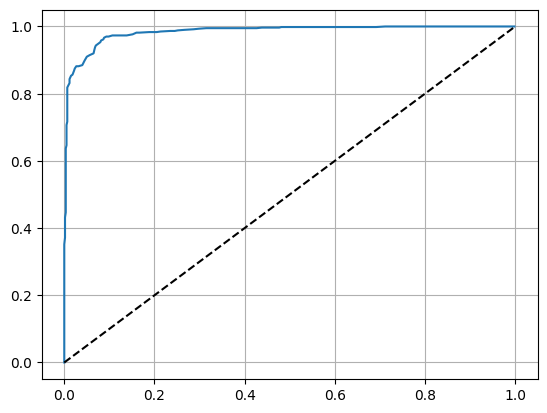

In [4]:
# Tracer de la courbe ROC :
# Pour cela on fait la même chose que précédemment ... et on fait varier le seuil de décision ...
VecProj = np.linalg.inv( np.dot( np.transpose(Xtrain) , Xtrain ) ) @ np.transpose(Xtrain) @ Ltrain
Lestim = Xtest @ VecProj

nbSeuils = 201
vecSeuils = np.linspace( np.min(Lestim) , np.max(Lestim) , nbSeuils )

idx=0
vecFP = np.zeros(nbSeuils)
vecFN = np.zeros(nbSeuils)
for seuil in vecSeuils :
    nbFP = np.sum( Lestim[Ltest==-1] > seuil)
    nbFN = np.sum( Lestim[Ltest==1] <= seuil)
    vecFP[idx] = nbFP / np.sum( Ltest==-1 )
    vecFN[idx]  = nbFN / np.sum( Ltest==1 )
    idx+=1

#CODE MANQUANT !!!

plt.figure()
plt.plot(vecFP , 1-vecFN)
plt.plot([0, 1 ] ,[0,1], '--k')
plt.grid()
plt.show()


0.5409780597343378
200.0


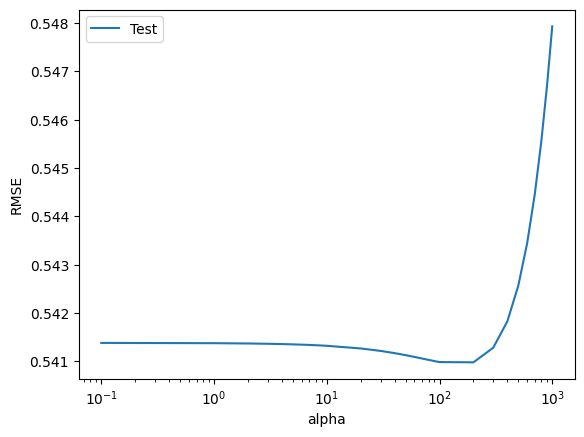

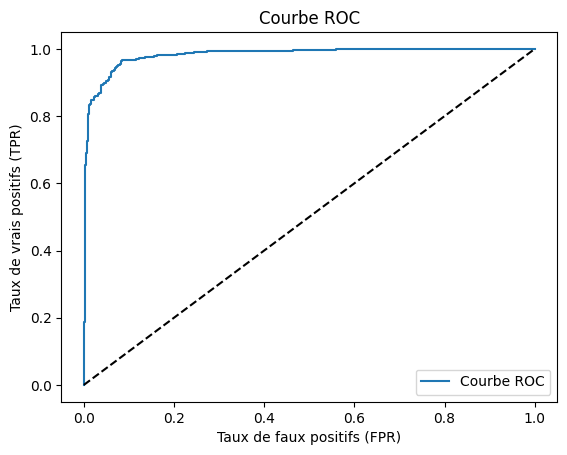

In [16]:
# POUR CONTINUER :
# Vous pouvez refaire la même chose en utilisant sklearn ...
# qui contient tous les outils/fonctions pour faire cela très simple.
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

alphas = [1e-1, 1, 2, 3, 4, 5, 6, 7, 8, 9, 1e1, 2e1, 3e1, 4e1, 5e1, 6e1, 7e1, 8e1, 9e1, 1e2, 2e2, 3e2, 4e2, 5e2, 6e2, 7e2, 8e2, 9e2, 1e3]
rmse_test_ridge=[]
# Instantiate a ridge model
for a in alphas:
    model = Ridge(alpha=a)
    model.fit(Xtrain, Ltrain)
    Lestim_test = model.predict(Xtest)
    rmse_test_ridge.append(np.sqrt(mean_squared_error(Ltest, Lestim_test)))
plt.figure()
plt.semilogx(alphas, rmse_test_ridge, label='Test')
print(min(rmse_test_ridge))
print(alphas[rmse_test_ridge.index(min(rmse_test_ridge))])
plt.xlabel('alpha')
plt.ylabel('RMSE')
plt.legend()
plt.show()

model_final = Ridge(alpha = 200)
model.fit(Xtrain, Ltrain)
Lestim_test = model.predict(Xtest)

from sklearn.metrics import roc_curve
fpr, tpr, seuils = roc_curve(Ltest, Lestim_test)

plt.plot(fpr, tpr, label='Courbe ROC')
plt.plot([0, 1], [0, 1], '--k')
plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR)')
plt.title('Courbe ROC')
plt.legend(loc='lower right')
plt.show()